# 지도학습_회귀분석2_고객별연간지출액예측

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("./data/ecommerce.csv")
data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [4]:
data.describe(include='all')

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500,500,500,500.000000,500.000000,500.000000,500.000000,500.000000
unique,500,500,138,NaN,NaN,NaN,NaN,NaN
top,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Teal,NaN,NaN,NaN,NaN,NaN
freq,1,1,7,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,33.053194,12.052488,37.060445,3.533462,499.314038
std,NaN,NaN,NaN,0.992563,0.994216,1.010489,0.999278,79.314782
min,NaN,NaN,NaN,29.532429,8.508152,33.913847,0.269901,256.670582
25%,NaN,NaN,NaN,32.341822,11.388153,36.349257,2.930450,445.038277
50%,NaN,NaN,NaN,33.082008,11.983231,37.069367,3.533975,498.887875
75%,NaN,NaN,NaN,33.711985,12.753850,37.716432,4.126502,549.313828


<Axes: >

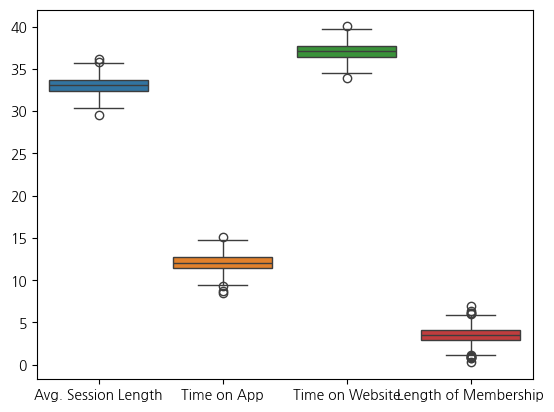

In [5]:
sns.boxplot(data.drop('Yearly Amount Spent', axis=1))

In [6]:
data.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [7]:
data = data.drop(['Email', 'Address', 'Avatar'], axis=1)
data

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438
496,34.702529,11.695736,37.190268,3.576526,529.049004
497,32.646777,11.499409,38.332576,4.958264,551.620145
498,33.322501,12.391423,36.840086,2.336485,456.469510


In [8]:
cols = data.columns[:-1]
cols

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership'],
      dtype='object')

============================== Avg. Session Length ==============================


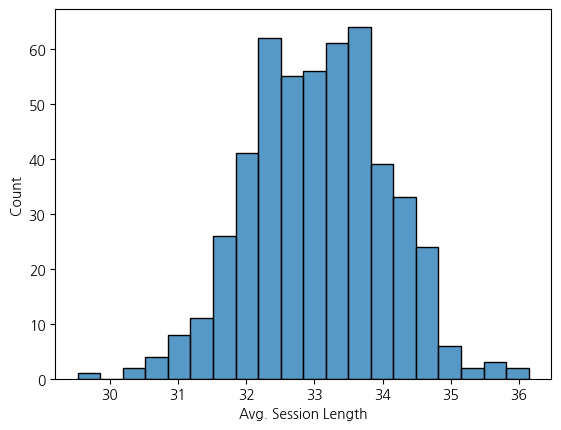

============================== Time on App ==============================


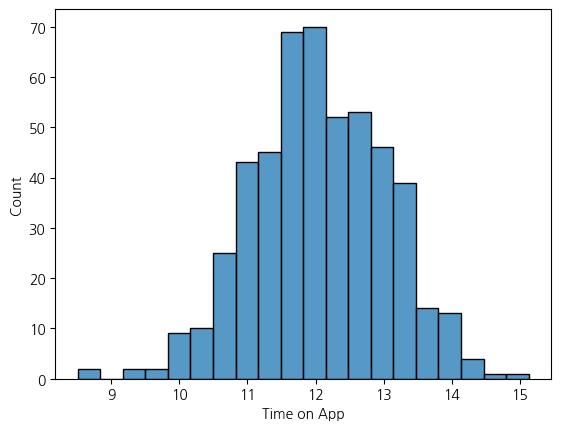

============================== Time on Website ==============================


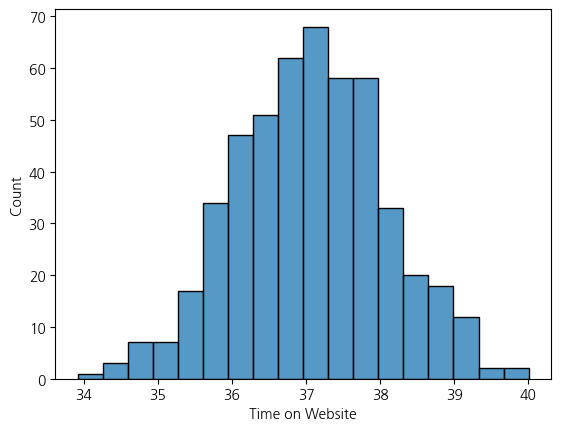

============================== Length of Membership ==============================


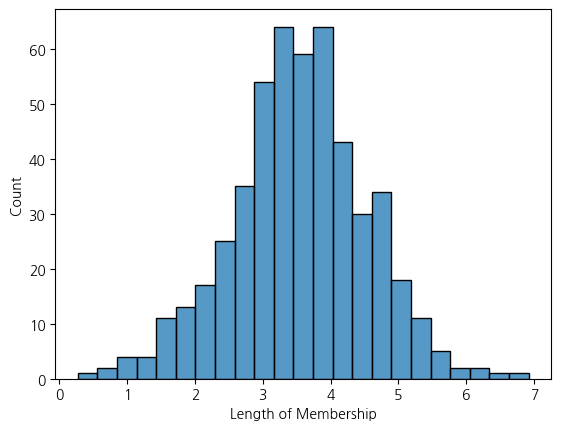

In [9]:
for col in cols:
    print("=" * 30, col, "=" * 30)
    sns.histplot(data[col])
    plt.show()
    

In [10]:
data.corr()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


<Axes: >

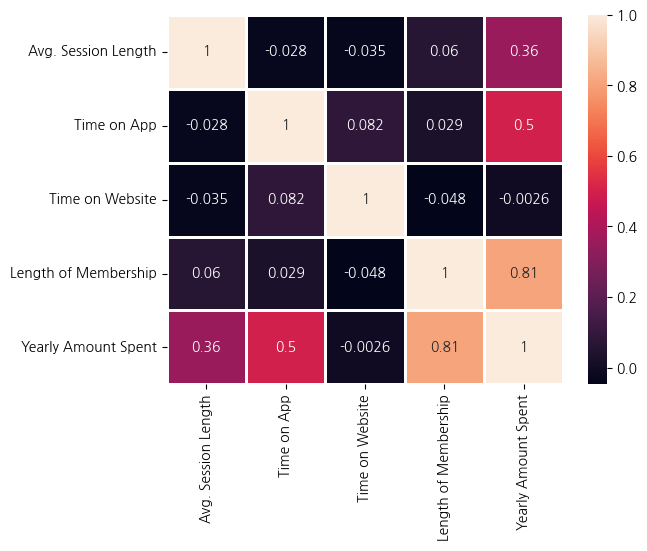

In [11]:
sns.heatmap(data.corr(), annot=True, linewidth=1)

# 데이터 홀드아웃, 스케일링, 분석

In [12]:
X = data[cols]
X

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573
496,34.702529,11.695736,37.190268,3.576526
497,32.646777,11.499409,38.332576,4.958264
498,33.322501,12.391423,36.840086,2.336485


In [13]:
data.columns

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [16]:
y = data['Yearly Amount Spent']
y

0      587.951054
1      392.204933
2      487.547505
3      581.852344
4      599.406092
          ...    
495    573.847438
496    529.049004
497    551.620145
498    456.469510
499    497.778642
Name: Yearly Amount Spent, Length: 500, dtype: float64

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# standard scaler로 독립변수 단위 맞춤

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
ss = StandardScaler()
ss.fit(X_train)
ss_X_train = pd.DataFrame(ss.transform(X_train), index= X_train.index, columns=X_train.columns)
ss_X_valid = pd.DataFrame(ss.transform(X_valid), index= X_valid.index, columns=X_valid.columns)

In [21]:
ss_X_train

,Avg. Session Length,Time on App,Time on Website,Length of Membership
249,0.728756,-0.140376,-0.173216,0.065197
433,1.233670,-0.235492,-0.700765,-1.413095
19,-0.449465,1.935961,0.166982,0.483620
322,0.206170,-1.328388,-0.860896,0.505068
332,0.084123,-0.321354,0.899668,-1.342230
...,...,...,...,...
106,-0.780032,0.133039,-0.854333,0.208220
270,0.958189,0.900460,1.607973,-0.284756
348,-1.265871,-1.173271,-2.088751,-0.428040
435,-0.812250,2.079565,0.002649,0.188979


In [22]:
ss_X_valid

,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,-0.997132,-1.713455,1.991749,-0.130046
73,-0.256010,0.761003,0.010579,0.276169
374,-1.635907,-1.960221,1.006187,0.652866
155,-0.620106,1.402969,0.214506,-0.610417
104,-1.694561,-1.065741,1.036687,-0.135598
...,...,...,...,...
347,0.718270,-0.754847,0.800082,1.529081
86,0.827716,0.460923,0.129021,-0.874853
75,-1.025263,0.180722,1.682520,-0.435901
438,-0.924682,-2.014653,0.158072,-0.032122


# 다중 선형 회귀분석

In [23]:
# statsmodels python 문법
import statsmodels.api as sm

In [24]:
# 상수항 추가
ss_X_train_const = sm.add_constant(ss_X_train)
ss_X_valid_const = sm.add_constant(ss_X_valid)

In [25]:
ss_X_train_const

,const,Avg. Session Length,Time on App,Time on Website,Length of Membership
249,1.0,0.728756,-0.140376,-0.173216,0.065197
433,1.0,1.233670,-0.235492,-0.700765,-1.413095
19,1.0,-0.449465,1.935961,0.166982,0.483620
322,1.0,0.206170,-1.328388,-0.860896,0.505068
332,1.0,0.084123,-0.321354,0.899668,-1.342230
...,...,...,...,...,...
106,1.0,-0.780032,0.133039,-0.854333,0.208220
270,1.0,0.958189,0.900460,1.607973,-0.284756
348,1.0,-1.265871,-1.173271,-2.088751,-0.428040
435,1.0,-0.812250,2.079565,0.002649,0.188979


In [26]:
ss_X_valid_const

,const,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,1.0,-0.997132,-1.713455,1.991749,-0.130046
73,1.0,-0.256010,0.761003,0.010579,0.276169
374,1.0,-1.635907,-1.960221,1.006187,0.652866
155,1.0,-0.620106,1.402969,0.214506,-0.610417
104,1.0,-1.694561,-1.065741,1.036687,-0.135598
...,...,...,...,...,...
347,1.0,0.718270,-0.754847,0.800082,1.529081
86,1.0,0.827716,0.460923,0.129021,-0.874853
75,1.0,-1.025263,0.180722,1.682520,-0.435901
438,1.0,-0.924682,-2.014653,0.158072,-0.032122


In [27]:
lr = sm.OLS(y_train, ss_X_train_const).fit()
print(lr.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.985
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     6676.
Date:                 Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                         10:36:05   Log-Likelihood:                -1480.1
No. Observations:                  400   AIC:                             2970.
Df Residuals:                      395   BIC:                             2990.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

* 위의 모델의 설명력 adj.r-squared: 0.985
* p=value: 0.00 유의수준 0.05보다 작다.
* 회귀식은 y = (25.2504 * Avg. Session Length) + (38.7035 * Time on App) + (63.5432 * Length of Membership) + 501.9922 이다.

# 회귀분석의 평가지표
* MSE(Mean Squared Error): 평균제곱오차 - 회귀선과 데이터간의 오차 - 잔차 (분산)
* RMSE(Root Mean Squared Error): 루트평균제곱오차 - 평균제곱오차를 다시 원래 데이터 단위로 되돌린 것(표준편차)

In [28]:
from sklearn.metrics import mean_squared_error

In [29]:
# 회귀 분석 모델로 예측
pred = lr.predict(ss_X_valid_const)
print("MSE:",  mean_squared_error(y_valid, pred))
print("RMSE:",  np.sqrt(mean_squared_error(y_valid, pred)))

MSE: 109.8637411839404
RMSE: 10.481590584636495


# 산점도 회귀선 그리기

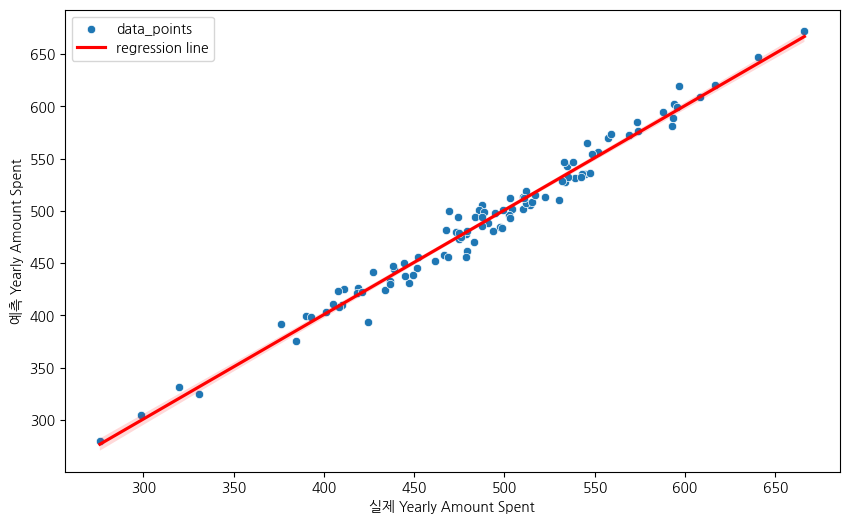

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_valid, y=pred, label='data_points')
sns.regplot(x=y_valid, y=pred, scatter=False, label="regression line", color='red')
plt.xlabel("실제 Yearly Amount Spent")
plt.ylabel("예측 Yearly Amount Spent")
plt.legend()
plt.show()

R 문법으로 statsmodels 회귀분석 하기

In [31]:
# import statsmodels.api as sm - python 방식
from statsmodels.formula.api import ols

R 문법으로 분석할 때는 독립변수와 종속변수를 합쳐서 하나의 DataFrame으로 해야 함

In [32]:
train_data = pd.concat([ss_X_train, y_train], axis=1)
train_data 

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
249,0.728756,-0.140376,-0.173216,0.065197,518.786483
433,1.233670,-0.235492,-0.700765,-1.413095,434.144202
19,-0.449465,1.935961,0.166982,0.483620,605.061039
322,0.206170,-1.328388,-0.860896,0.505068,478.262126
332,0.084123,-0.321354,0.899668,-1.342230,424.202827
...,...,...,...,...,...
106,-0.780032,0.133039,-0.854333,0.208220,494.551861
270,0.958189,0.900460,1.607973,-0.284756,540.995739
348,-1.265871,-1.173271,-2.088751,-0.428040,392.810345
435,-0.812250,2.079565,0.002649,0.188979,571.216005


In [33]:
valid_data = pd.concat([ss_X_valid, y_valid], axis=1)
valid_data 

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
361,-0.997132,-1.713455,1.991749,-0.130046,401.033135
73,-0.256010,0.761003,0.010579,0.276169,534.777188
374,-1.635907,-1.960221,1.006187,0.652866,418.602742
155,-0.620106,1.402969,0.214506,-0.610417,503.978379
104,-1.694561,-1.065741,1.036687,-0.135598,410.069611
...,...,...,...,...,...
347,0.718270,-0.754847,0.800082,1.529081,593.156401
86,0.827716,0.460923,0.129021,-0.874853,487.379306
75,-1.025263,0.180722,1.682520,-0.435901,478.719357
438,-0.924682,-2.014653,0.158072,-0.032122,392.992256


In [37]:
train_data.columns = [col.replace(".", "").replace(" ", "_") for col in train_data.columns]
valid_data.columns = [col.replace(".", "").replace(" ", "_") for col in valid_data.columns]

In [38]:
train_data

,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
249,0.728756,-0.140376,-0.173216,0.065197,518.786483
433,1.233670,-0.235492,-0.700765,-1.413095,434.144202
19,-0.449465,1.935961,0.166982,0.483620,605.061039
322,0.206170,-1.328388,-0.860896,0.505068,478.262126
332,0.084123,-0.321354,0.899668,-1.342230,424.202827
...,...,...,...,...,...
106,-0.780032,0.133039,-0.854333,0.208220,494.551861
270,0.958189,0.900460,1.607973,-0.284756,540.995739
348,-1.265871,-1.173271,-2.088751,-0.428040,392.810345
435,-0.812250,2.079565,0.002649,0.188979,571.216005


In [39]:
valid_data

,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
361,-0.997132,-1.713455,1.991749,-0.130046,401.033135
73,-0.256010,0.761003,0.010579,0.276169,534.777188
374,-1.635907,-1.960221,1.006187,0.652866,418.602742
155,-0.620106,1.402969,0.214506,-0.610417,503.978379
104,-1.694561,-1.065741,1.036687,-0.135598,410.069611
...,...,...,...,...,...
347,0.718270,-0.754847,0.800082,1.529081,593.156401
86,0.827716,0.460923,0.129021,-0.874853,487.379306
75,-1.025263,0.180722,1.682520,-0.435901,478.719357
438,-0.924682,-2.014653,0.158072,-0.032122,392.992256


In [42]:
"+".join(train_data.columns[:-1])

'Avg_Session_Length+Time_on_App+Time_on_Website+Length_of_Membership'

In [44]:
# 'Yearly_Amount_Spent ~ 'Avg_Session_Length' + 'Time_on_App' + 'Time_on_Website' + 'Length_of_Membership'

In [43]:
model = ols('Yearly_Amount_Spent ~' + "+".join(train_data.columns[:-1]), data=train_data).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly_Amount_Spent   R-squared:                       0.985
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     6676.
Date:                 Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                         11:17:49   Log-Likelihood:                -1480.1
No. Observations:                  400   AIC:                             2970.
Df Residuals:                      395   BIC:                             2990.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             

In [45]:
model = ols("Yearly_Amount_Spent ~ Avg_Session_Length + Time_on_App + Time_on_Website + Length_of_Membership", data=train_data).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly_Amount_Spent   R-squared:                       0.985
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     6676.
Date:                 Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                         11:20:27   Log-Likelihood:                -1480.1
No. Observations:                  400   AIC:                             2970.
Df Residuals:                      395   BIC:                             2990.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             

# 사이킷런을 이용한 회귀분석

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
lr = LinearRegression()
lr.fit(ss_X_train, y_train)
pred = lr.predict(ss_X_valid)
print("MSE: ", mean_squared_error(y_valid, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, pred)))

MSE:  109.86374118394049
RMSE:  10.481590584636498


In [48]:
# y절편, intercept, const
print("y절편: ", lr.intercept_)

y절편:  501.9921512124531


In [49]:
# 각 변수의 회귀계수
print("각 변수의 회귀계수: ", lr.coef_)

각 변수의 회귀계수:  [25.25038131 38.70350139  0.31546926 63.54321107]


In [50]:
# 각 변수의 이름
print('각 변수의 이름: ', lr.feature_names_in_)

각 변수의 이름:  ['Avg. Session Length' 'Time on App' 'Time on Website'
 'Length of Membership']


In [51]:
model_coef = pd.DataFrame(dict(feature=lr.feature_names_in_, coef=lr.coef_))
model_coef

,feature,coef
0,Avg. Session Length,25.250381
1,Time on App,38.703501
2,Time on Website,0.315469
3,Length of Membership,63.543211


In [53]:
# r-squared
r2 = lr.score(ss_X_valid, y_valid)
print("r2: ", r2)

r2:  0.9778130629184125


In [54]:
result = pd.DataFrame(dict(y_valid=y_valid, pred=pred))
result

,y_valid,pred
361,401.033135,402.862301
73,534.777188,542.533257
374,418.602742,426.620119
155,503.978379,501.913864
104,410.069611,409.666655
...,...,...
347,593.156401,588.328629
86,487.379306,485.181373
75,478.719357,455.930701
438,392.992256,398.678207


In [55]:
result['편차'] = result['y_valid'] - result['pred']
result

,y_valid,pred,편차
361,401.033135,402.862301,-1.829165
73,534.777188,542.533257,-7.756069
374,418.602742,426.620119,-8.017377
155,503.978379,501.913864,2.064515
104,410.069611,409.666655,0.402956
...,...,...,...
347,593.156401,588.328629,4.827772
86,487.379306,485.181373,2.197933
75,478.719357,455.930701,22.788656
438,392.992256,398.678207,-5.685951


In [56]:
result['편차제곱'] = result['편차'] ** 2
result

,y_valid,pred,편차,편차제곱
361,401.033135,402.862301,-1.829165,3.345846
73,534.777188,542.533257,-7.756069,60.156606
374,418.602742,426.620119,-8.017377,64.278335
155,503.978379,501.913864,2.064515,4.262224
104,410.069611,409.666655,0.402956,0.162374
...,...,...,...,...
347,593.156401,588.328629,4.827772,23.307383
86,487.379306,485.181373,2.197933,4.830911
75,478.719357,455.930701,22.788656,519.322841
438,392.992256,398.678207,-5.685951,32.330042


In [57]:
result['평균편차제곱(MSE)'] = result['편차제곱'].mean()
result

,y_valid,pred,편차,편차제곱,평균편차제곱(MSE)
361,401.033135,402.862301,-1.829165,3.345846,109.863741
73,534.777188,542.533257,-7.756069,60.156606,109.863741
374,418.602742,426.620119,-8.017377,64.278335,109.863741
155,503.978379,501.913864,2.064515,4.262224,109.863741
104,410.069611,409.666655,0.402956,0.162374,109.863741
...,...,...,...,...,...
347,593.156401,588.328629,4.827772,23.307383,109.863741
86,487.379306,485.181373,2.197933,4.830911,109.863741
75,478.719357,455.930701,22.788656,519.322841,109.863741
438,392.992256,398.678207,-5.685951,32.330042,109.863741


In [58]:
result['루트평균편차제곱(RMSE)'] = result['평균편차제곱(MSE)'].apply(np.sqrt)
result

,y_valid,pred,편차,편차제곱,평균편차제곱(MSE),루트평균편차제곱(RMSE)
361,401.033135,402.862301,-1.829165,3.345846,109.863741,10.481591
73,534.777188,542.533257,-7.756069,60.156606,109.863741,10.481591
374,418.602742,426.620119,-8.017377,64.278335,109.863741,10.481591
155,503.978379,501.913864,2.064515,4.262224,109.863741,10.481591
104,410.069611,409.666655,0.402956,0.162374,109.863741,10.481591
...,...,...,...,...,...,...
347,593.156401,588.328629,4.827772,23.307383,109.863741,10.481591
86,487.379306,485.181373,2.197933,4.830911,109.863741,10.481591
75,478.719357,455.930701,22.788656,519.322841,109.863741,10.481591
438,392.992256,398.678207,-5.685951,32.330042,109.863741,10.481591



# 최소제곱법 (Least Squares Method)

회귀분석에서 가장 중요한 개념 중 하나는 **최소제곱법(Least Squares)** 입니다.

회귀모형은 다음과 같이 표현됩니다.

$$
y = \beta_0 + \beta_1 x + \epsilon
$$

- $y$ : 종속변수  
- $x$ : 독립변수  
- $\beta_0$ : 절편  
- $\beta_1$ : 회귀계수  
- $\epsilon$ : 오차

실제 데이터에서는 모든 점이 직선 위에 정확히 위치하지 않기 때문에 **잔차(residual)** 가 발생합니다.

$$
e_i = y_i - \hat{y_i}
$$

최소제곱법은 다음 값을 최소로 만드는 직선을 찾는 방법입니다.

$$
SSE = \sum (y_i - \hat{y_i})^2
$$

즉 **실제값과 예측값 차이의 제곱합을 최소로 만드는 직선**을 찾는 것이 최소제곱법입니다.


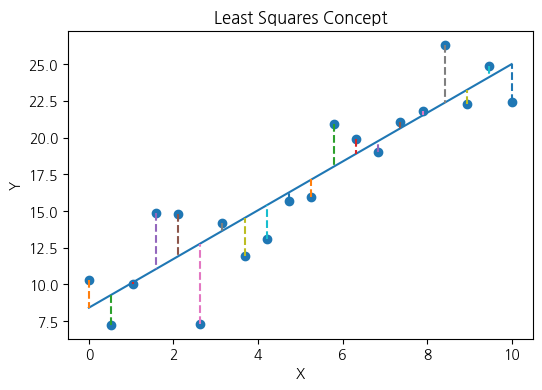

In [59]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

x = np.linspace(0,10,20)
y = 2*x + 5 + np.random.normal(0,3,20)

coef = np.polyfit(x,y,1)
line = coef[0]*x + coef[1]

plt.figure(figsize=(6,4))
plt.scatter(x,y)
plt.plot(x,line)

for i in range(len(x)):
    plt.plot([x[i],x[i]],[y[i],line[i]], linestyle="--")

plt.title("Least Squares Concept")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()



# 결정계수 (R-squared)

회귀모델이 데이터를 얼마나 잘 설명하는지를 나타내는 지표가 **R² (결정계수)** 입니다.

$$
R^2 = 1 - \frac{SSE}{SST}
$$

### SSE (Sum of Squared Error)

$$
SSE = \sum (y_i - \hat{y_i})^2
$$

모델이 설명하지 못한 오차입니다.

### SST (Total Sum of Squares)

$$
SST = \sum (y_i - \bar{y})^2
$$

데이터 전체의 변동성입니다.

R² 값의 해석

| R² 값 | 의미 |
|---|---|
| 0 | 모델 설명력 거의 없음 |
| 0.5 | 데이터 변동의 50% 설명 |
| 1 | 완벽한 예측 |


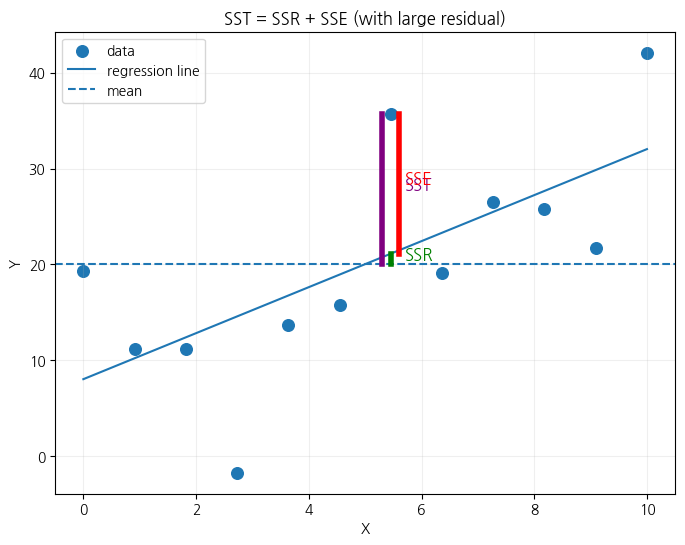

In [61]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)

# 데이터 생성 (오차 크게)
x = np.linspace(0,10,12)
y = 3*x + 5 + np.random.normal(0,8,len(x))

# 일부러 큰 오차 하나 만들기
y[6] += 15

# 회귀선
coef = np.polyfit(x,y,1)
y_pred = coef[0]*x + coef[1]

# 평균
y_mean = np.mean(y)

plt.figure(figsize=(8,6))

plt.scatter(x,y,s=70,label="data")
plt.plot(x,y_pred,label="regression line")
plt.axhline(y_mean,linestyle="--",label="mean")

# 설명용 포인트
i = 6

# SST
plt.plot(
    [x[i]-0.15,x[i]-0.15],
    [y_mean,y[i]],
    color="purple",
    linewidth=4
)

# SSR
plt.plot(
    [x[i],x[i]],
    [y_mean,y_pred[i]],
    color="green",
    linewidth=4
)

# SSE
plt.plot(
    [x[i]+0.15,x[i]+0.15],
    [y_pred[i],y[i]],
    color="red",
    linewidth=4
)

plt.text(x[i]+0.25,(y_mean+y[i])/2,"SST",color="purple",fontsize=12)
plt.text(x[i]+0.25,(y_mean+y_pred[i])/2,"SSR",color="green",fontsize=12)
plt.text(x[i]+0.25,(y_pred[i]+y[i])/2,"SSE",color="red",fontsize=12)

plt.title("SST = SSR + SSE (with large residual)")
plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.grid(alpha=0.2)

plt.show()